#### 데이터전처리_로지스틱분류실험 251029

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("./credit_risk_dataset.csv") 
df.head() 

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [3]:
df.shape

(32581, 12)

#### 상관관계 시각화

In [4]:
corr_x = df.select_dtypes(['float', 'int']).corr()

person_age와 cb_person_cred_hist_lengh 사이에 상관관계 있어보이므로 나중에 실험필요


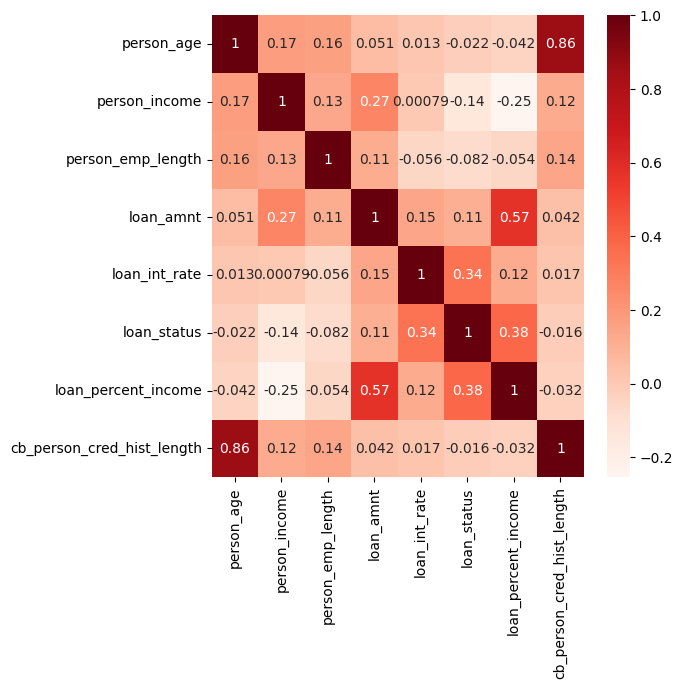

In [5]:
print("person_age와 cb_person_cred_hist_lengh 사이에 상관관계 있어보이므로 나중에 실험필요")
plt.figure(figsize=(6, 6))  
sns.heatmap(corr_x, annot=True, cmap='Reds')  
plt.show()

#### 상관계수 높은 컬럼 시각화

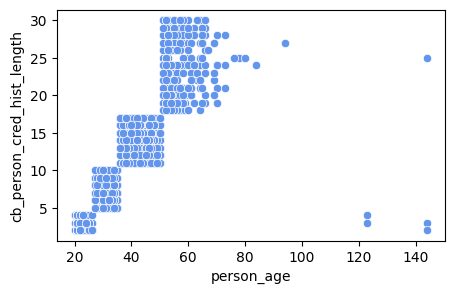

In [6]:
plt.figure(figsize=(5,3))
sns.scatterplot(data=df, x='person_age', y='cb_person_cred_hist_length', color='cornflowerblue')  
plt.show() 

In [7]:
print("미리 봐뒀던 loan_int_rate 제거할거고 (사후적인 변수라서), \n상관계수 높은 변수는 제거할지 말지 고민")

미리 봐뒀던 loan_int_rate 제거할거고 (사후적인 변수라서), 
상관계수 높은 변수는 제거할지 말지 고민


In [8]:
print("loan_int_rate랑 loan_grade(target)을 ANOVA나 Kruskal 검정 해봐야하나? ")

loan_int_rate랑 loan_grade(target)을 ANOVA나 Kruskal 검정 해봐야하나? 


In [9]:
df = df.drop(['loan_int_rate'], axis=1) 
df.head() 

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,1,0.55,Y,4


#### 결측치 확인 및 채워넣기 

In [10]:
df.isnull().sum()

person_age                      0
person_income                   0
person_home_ownership           0
person_emp_length             895
loan_intent                     0
loan_grade                      0
loan_amnt                       0
loan_status                     0
loan_percent_income             0
cb_person_default_on_file       0
cb_person_cred_hist_length      0
dtype: int64

In [11]:
df = df.fillna(0)
df.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

In [12]:
df.select_dtypes('object').head()

,person_home_ownership,loan_intent,loan_grade,cb_person_default_on_file
0,RENT,PERSONAL,D,Y
1,OWN,EDUCATION,B,N
2,MORTGAGE,MEDICAL,C,N
3,RENT,MEDICAL,C,N
4,RENT,MEDICAL,C,Y


#### 데이터 나누기 

In [13]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_status', 'loan_percent_income', 'cb_person_default_on_file',
       'cb_person_cred_hist_length'],
      dtype='object')

In [14]:
features = list(df.columns)
features.remove('loan_grade')

X = df[features]
y = df['loan_grade']

#### 명목형변수 변경   
- 우선은 one-hot-encoding으로 / label encoding도 고려해보기 

In [15]:
X.select_dtypes('object').head()

,person_home_ownership,loan_intent,cb_person_default_on_file
0,RENT,PERSONAL,Y
1,OWN,EDUCATION,N
2,MORTGAGE,MEDICAL,N
3,RENT,MEDICAL,N
4,RENT,MEDICAL,Y


In [16]:
# one-hot encoding
# X = pd.get_dummies(X, dtype=float)
# X.shape

In [17]:
# label encoding
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
X['person_home_ownership'] = encoder.fit_transform(X['person_home_ownership'])
X['loan_intent'] = encoder.fit_transform(X['loan_intent'])
X['cb_person_default_on_file'] = encoder.fit_transform(X['cb_person_default_on_file'])

In [18]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  int32  
 3   person_emp_length           32581 non-null  float64
 4   loan_intent                 32581 non-null  int32  
 5   loan_amnt                   32581 non-null  int64  
 6   loan_status                 32581 non-null  int64  
 7   loan_percent_income         32581 non-null  float64
 8   cb_person_default_on_file   32581 non-null  int32  
 9   cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(2), int32(3), int64(5)
memory usage: 2.1 MB


In [19]:
# 트레이닝/테스트 데이터 분할 
from sklearn.model_selection import train_test_split
X_tn, X_te, y_tn, y_te = train_test_split(X, y, random_state=0, stratify=y)

In [20]:
# 데이터 표준화
from sklearn.preprocessing import StandardScaler 
std_scale = StandardScaler()
std_scale.fit(X_tn)
X_tn_std = std_scale.transform(X_tn)
X_te_std = std_scale.transform(X_te)

In [21]:
y_tn.shape

(24435,)

In [22]:
df_tmp = pd.concat([pd.DataFrame(X_tn_std, columns=X.columns), pd.Series(y_tn)], axis=1)
df_tmp.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_amnt,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_grade
0,-0.434636,-0.504225,0.919611,0.082604,0.844228,-0.709113,-0.52857,-0.188691,-0.462059,-0.940608,D
1,1.925335,-0.694044,-1.173932,-1.109197,0.266004,-1.272878,-0.52857,-0.938605,-0.462059,2.752431,NaN
2,-0.591968,0.171476,0.919611,-0.632477,-1.468667,-0.247852,-0.52857,-0.657387,-0.462059,-0.694405,C
3,1.610672,0.062492,0.919611,-0.394116,-1.468667,0.193698,-0.52857,-0.188691,-0.462059,2.506228,C
4,-0.591968,-0.451290,0.919611,-0.632477,0.844228,-0.405548,-0.52857,0.186266,-0.462059,-0.940608,C


In [23]:
df_tmp.shape

(30584, 11)

In [24]:
x_cols = list(df.columns)
x_cols.remove('loan_grade')

In [25]:
len(x_cols)

10

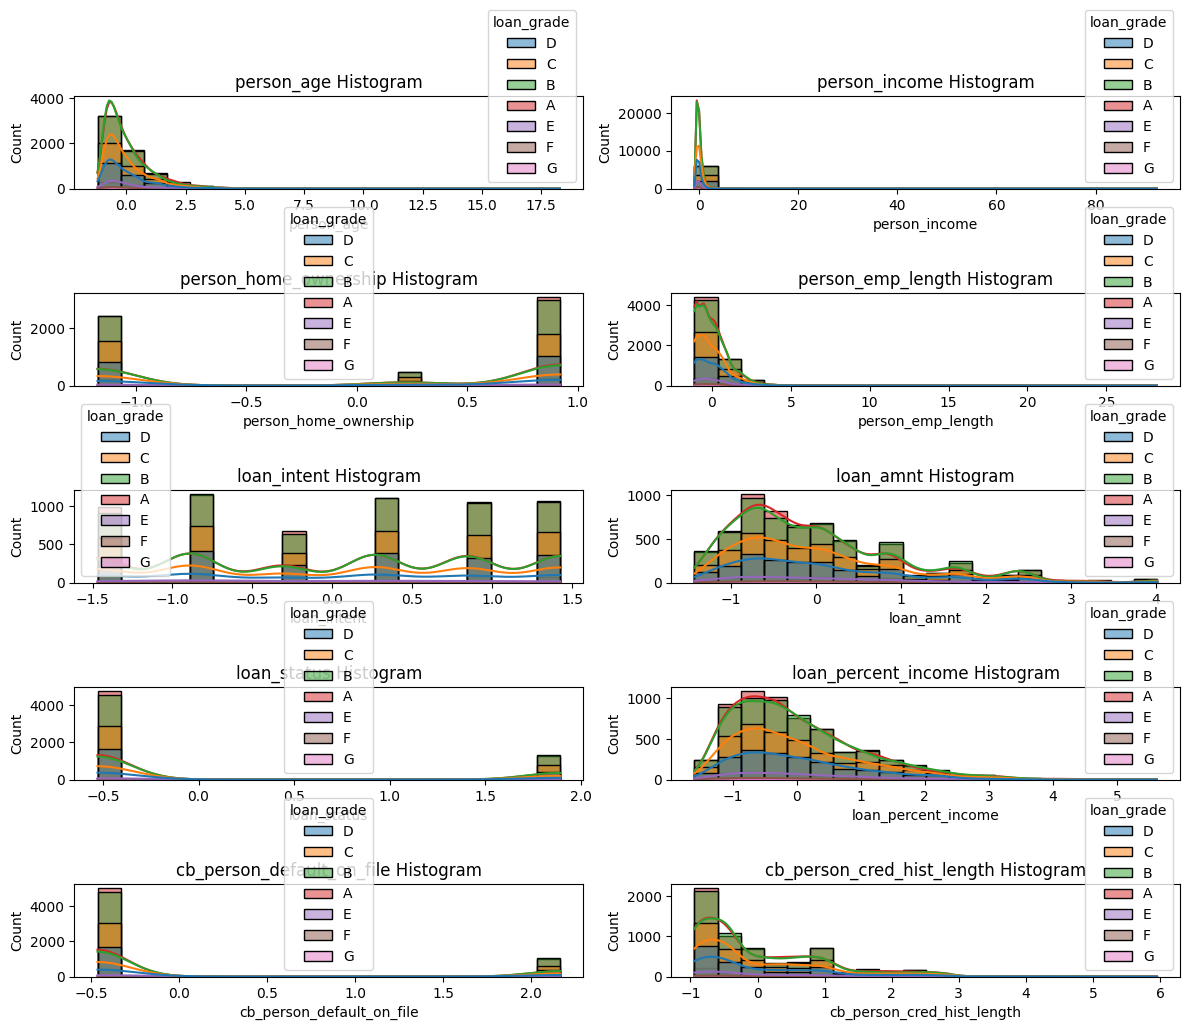

In [26]:
fig, axes = plt.subplots(5, 2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(x_cols):
    sns.histplot(data=df_tmp, x=col, hue='loan_grade', bins=20, kde=True, ax=axes[i], color='cornflowerblue')
    axes[i].set_title(f'{col} Histogram')

plt.tight_layout()
plt.show()

#### 로지스틱 분류 

In [27]:
# 로지스틱 회귀분석 (L2 제약식 적용)
from sklearn.linear_model import LogisticRegression
clf_logi_l2 = LogisticRegression(penalty='l2')
clf_logi_l2.fit(X_tn_std, y_tn)

LogisticRegression()

In [28]:
# 로지스틱 회귀분석 모형 (L2 제약식 적용) 추정 계수
print(clf_logi_l2.coef_)
print(clf_logi_l2.intercept_)

[[ 0.03585375  0.17736685 -0.11762167  0.06647899 -0.11524352 -0.72460673
  -0.98518425  0.46060743 -2.59346527 -0.09320863]
 [ 0.03355334  0.13311488  0.13305033  0.01514318 -0.08020197 -0.35328581
  -0.79529527  0.35916878 -2.57733    -0.07530595]
 [ 0.02342789  0.16421436  0.16558353 -0.03151835 -0.13742844 -0.46842238
  -0.65356991  0.33803176  1.04694855 -0.014253  ]
 [ 0.02016196 -0.09462948  0.08006274  0.04756524 -0.02310228  0.06159264
   0.20977177 -0.16896366  1.05943672 -0.01874579]
 [ 0.13122724 -0.02034755  0.10096818 -0.06667038  0.01773741  0.29864862
   0.33310442 -0.2724309   1.00037653 -0.14284293]
 [ 0.08199713 -0.15204664 -0.10514844 -0.1274851  -0.0222136   0.52132399
   0.43613671 -0.33477708  1.0140411  -0.01838034]
 [-0.32622131 -0.20767241 -0.25689466  0.09648642  0.3604524   0.66474967
   1.45503654 -0.38163633  1.04999237  0.36273664]]
[ 1.65214349  1.70439806  2.19964276  1.28353768 -0.18153115 -1.79263056
 -4.86556027]


In [29]:
# 예측
pred_logistic = clf_logi_l2.predict(X_te_std)
print(pred_logistic)

['B' 'A' 'A' ... 'D' 'B' 'A']


In [30]:
# confusion matrix 확인
from sklearn.metrics import confusion_matrix
conf_matrix = confusion_matrix(y_te, pred_logistic)
print(conf_matrix)

[[1777  899    0   18    0    0    0]
 [1239 1336    0   38    0    0    0]
 [ 369  422  685  139    0    0    0]
 [ 115  276  209  307    0    0    0]
 [  26   81   48   86    0    0    0]
 [   2   26    9   23    0    0    0]
 [   1    1    0   14    0    0    0]]


['A', 'B', 'C', 'D', 'E', 'F', 'G']


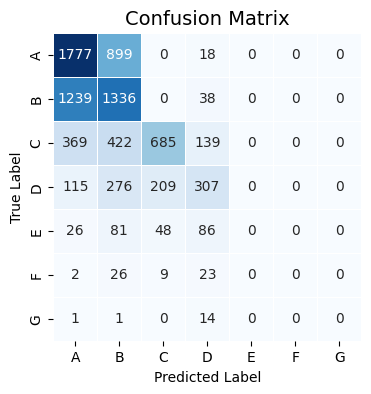

In [31]:
labels = sorted(df['loan_grade'].unique())
print(labels)

plt.figure(figsize=(4,4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels, 
            linewidths=0.5, cbar=False, square=True)

plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [32]:
# 분류 레포트 확인
from sklearn.metrics import classification_report
class_report = classification_report(y_te, pred_logistic)
print(class_report)

              precision    recall  f1-score   support

           A       0.50      0.66      0.57      2694
           B       0.44      0.51      0.47      2613
           C       0.72      0.42      0.53      1615
           D       0.49      0.34      0.40       907
           E       0.00      0.00      0.00       241
           F       0.00      0.00      0.00        60
           G       0.00      0.00      0.00        16

    accuracy                           0.50      8146
   macro avg       0.31      0.28      0.28      8146
weighted avg       0.50      0.50      0.49      8146



In [33]:
print("loan_int_rate변수 제거하니까 성능 엄청낮음.\n그리고 클래스별로 비율이 달라서인지 undersampling이 필요할 것 같음.")
print("클래스가 다양하니까 데이터도 더 많이 필요할것같고, one-hot encoding보다는 labelencoder가 필요할 것 같음.")
print("labelEncoder로 해도 성능 잘 안오름 ..")

loan_int_rate변수 제거하니까 성능 엄청낮음.
그리고 클래스별로 비율이 달라서인지 undersampling이 필요할 것 같음.
클래스가 다양하니까 데이터도 더 많이 필요할것같고, one-hot encoding보다는 labelencoder가 필요할 것 같음.
labelEncoder로 해도 성능 잘 안오름 ..


In [34]:
print("이상치를 조금 제거하고 돌려봐야하나 싶음")

이상치를 조금 제거하고 돌려봐야하나 싶음


#### 그래디언트 부스팅 

In [35]:
# 그래디언트부스팅 학습
from sklearn.ensemble import GradientBoostingClassifier

clf_gbt = GradientBoostingClassifier(max_depth=2, learning_rate=0.1, random_state=0)

clf_gbt.fit(X_tn_std, y_tn)

GradientBoostingClassifier(max_depth=2, random_state=0)

In [36]:
#예측
pred_gboost = clf_gbt.predict(X_te_std)
print(pred_gboost)

['A' 'A' 'A' ... 'D' 'B' 'A']


In [40]:
# confusion matrix 확인
from sklearn.metrics import confusion_matrix
conf_matrix = confusion_matrix(y_te, pred_gboost)
print(conf_matrix)

[[1746  907    1   40    0    0    0]
 [1180 1371    1   60    0    0    1]
 [ 376  393  687  159    0    0    0]
 [ 121  233  209  344    0    0    0]
 [  26   73   48   93    1    0    0]
 [   6   21    9   24    0    0    0]
 [   0    1    1   14    0    0    0]]


['A', 'B', 'C', 'D', 'E', 'F', 'G']


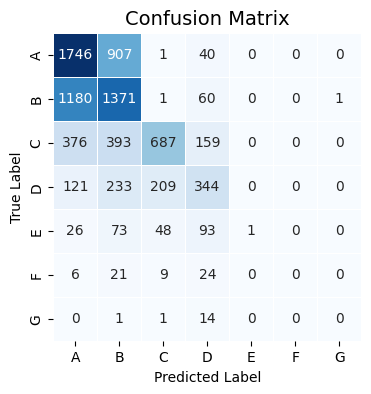

In [41]:
labels = sorted(df['loan_grade'].unique())
print(labels)

plt.figure(figsize=(4,4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels, 
            linewidths=0.5, cbar=False, square=True)

plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [42]:
# 분류 레포트 확인
from sklearn.metrics import classification_report
class_report = classification_report(y_te, pred_gboost)
print(class_report)

              precision    recall  f1-score   support

           A       0.51      0.65      0.57      2694
           B       0.46      0.52      0.49      2613
           C       0.72      0.43      0.53      1615
           D       0.47      0.38      0.42       907
           E       1.00      0.00      0.01       241
           F       0.00      0.00      0.00        60
           G       0.00      0.00      0.00        16

    accuracy                           0.51      8146
   macro avg       0.45      0.28      0.29      8146
weighted avg       0.54      0.51      0.50      8146

